# Podela na trening i izdvojeni test skup

Ovu podelu pravimo **posle** uklanjanja duplikata. Cilj je da dobijemo podatke za razvoj modela i zaseban skup za njegovu završnu proveru. Notebook poziva istu funkciju kao komandna linija, ali ne upisuje CSV fajlove.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.data_loading import load_raw_sms
from src.preprocessing import prepare_sms
from src.split_data import RANDOM_SEED, TEST_FRACTION, split_sms

clean = prepare_sms(load_raw_sms())
train, test = split_sms(clean)
print('Ukupno:', len(clean), 'Trening:', len(train), 'Test:', len(test))

Ukupno: 5158 Trening: 4127 Test: 1031


## Zašto stratifikovana podela?

Skup ima mnogo više `ham` nego `spam` poruka. Zato nasumično biramo približno 20% **iz svake klase** za test. Tako odnos klasa ostaje sličan u oba dela. `random_seed` omogućava da isti kod ponovo dobije istu podelu na istim podacima.

In [2]:
print('Udeo testa:', TEST_FRACTION, 'Nasumično seme:', RANDOM_SEED)
summary = pd.DataFrame({
    'trening_broj': train['label'].value_counts(),
    'trening_%': train['label'].value_counts(normalize=True).mul(100).round(2),
    'test_broj': test['label'].value_counts(),
    'test_%': test['label'].value_counts(normalize=True).mul(100).round(2),
}).reindex(['ham', 'spam'])
summary

Udeo testa: 0.2 Nasumično seme: 42


,trening_broj,trening_%,test_broj,test_%
label,,,,
ham,3613,87.55,903,87.58
spam,514,12.45,128,12.42


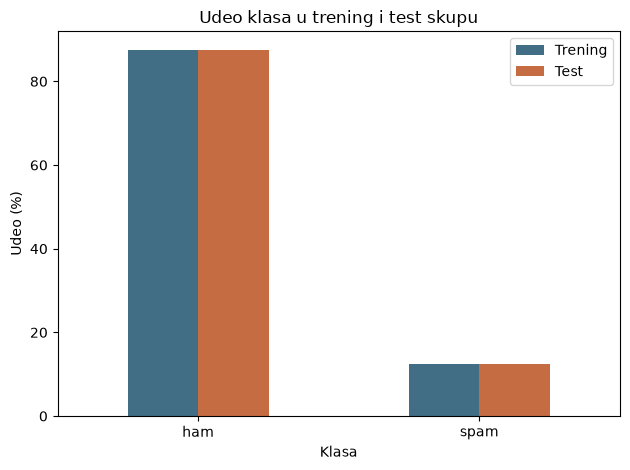

In [3]:
ax = summary[['trening_%', 'test_%']].plot.bar(rot=0, color=['#416e84', '#c66c43'])
ax.set(title='Udeo klasa u trening i test skupu', xlabel='Klasa', ylabel='Udeo (%)')
ax.legend(['Trening', 'Test'])
plt.tight_layout()
plt.show()

## Provera da nema preklapanja

Ako se isti tekst nalazi u oba dela, test ne bi bio nezavisan. Proveravamo samo broj preklapanja; **ne pregledamo tekstove test poruka** i ne koristimo test za odluke o modelu.

In [4]:
overlap = set(train['text']) & set(test['text'])
print('Isti tekst u oba skupa:', len(overlap))
print('Svi redovi sačuvani:', len(train) + len(test) == len(clean))
assert not overlap
assert len(train) + len(test) == len(clean)

Isti tekst u oba skupa: 0
Svi redovi sačuvani: True


## Šta ide dalje?

Rečnik tokena napravićemo samo iz `train['text']`. Njime ćemo kasnije pretvoriti i trening i test poruke u brojeve. U cross-validaciji dodatno ćemo deliti trening deo, uz nov rečnik za svaki trening fold. Izdvojeni test ostaje po strani do završne procene.